In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import confusion_matrix, accuracy_score


In [ ]:
# Kaggle dataset https://www.kaggle.com/datasets/gabrielluizone/high-school-alcoholism-and-academic-performance?resource=download&select=student-lpor.csv
# Import CSV file
csv_file = "https://drive.google.com/uc?id=1AHR8KrgBjZ1oyCy0E3d29qfmOwa2lM5p"
df = pd.read_csv(csv_file)
df.head()


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,romantic,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,4,3,4,1,1,3,4,0,11
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,no,5,3,3,1,1,3,2,9,11
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,no,4,3,2,2,3,3,6,12,13
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,3,2,2,1,1,5,0,14,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,4,3,2,1,2,5,0,11,13


Preliminary data anlysis

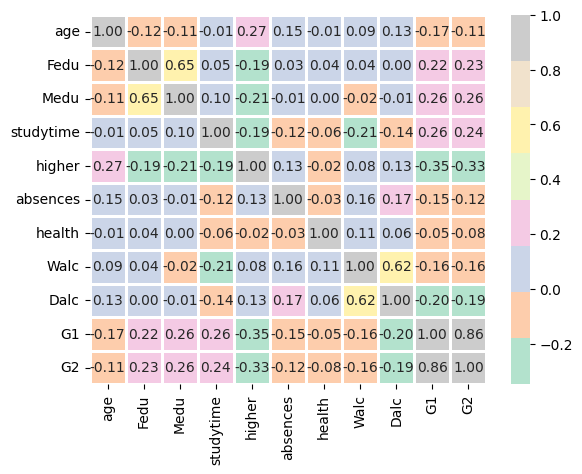

In [ ]:
# Make higher education into numeric binary
df['higher'] = df['higher'].map({'yes': 0, 'no': 1})

# Crete heatmap to find correlations
sns.heatmap(df[['age', 'Fedu', 'Medu', 'studytime', 'higher', 'absences',
                'health', 'Walc','Dalc', 'G1', 'G2']]
            .corr(), annot=True, fmt='.2f', cmap='Pastel2', linewidths=2)
plt.show()

In [ ]:
# Remove unnecessary columns
df = df[['age', 'Fedu', 'Medu', 'studytime', 'higher', 'absences', 'health', 'Dalc', 'Walc', 'G1', 'G2' ]]
# Update column names
df.columns = ['Age', 'Fathers Ed.', 'Mothers Ed.', 'Study Time', 'Desire for Higher Ed.', 'Absences',
              'Health', 'Weekday Alcohol Consumption', 'Weekend Alcohol Consumption',
              '1st Semester Grade', '2nd Semester Grade']
df.head()

,Age,Fathers Ed.,Mothers Ed.,Study Time,Desire for Higher Ed.,Absences,Health,Weekday Alcohol Consumption,Weekend Alcohol Consumption,1st Semester Grade,2nd Semester Grade
0,18,4,4,2,0,4,3,1,1,0,11
1,17,1,1,2,0,2,3,1,1,9,11
2,15,1,1,2,0,6,3,2,3,12,13
3,15,2,4,3,0,0,5,1,1,14,14
4,16,3,3,2,0,0,5,1,2,11,13


# Data Dictionary
| Variable               | Description
|------------------------|----------------------------------------------------
| Age                   | Student's age
| Fathers Ed.           | Student's father's education level (0 - none, 1 - Elementary School 1, 2 - Elementary School 2, 3 - High School or 4 - Higher Education)
| Mothers Ed.           | Student's mother's education level (0 - none, 1 - Elementary School 1, 2 - Elementary School 2, 3 - High School or 4 - Higher Education)
| Study Time            | Student's weekly study time (1 - <2 hours, 2 - 2 to 5 hours, 3 - 5 to 10 hours, or 4 - >10 hours)
| Desire for Higher Ed. | Student's desire for higher education
| Absences              | Student's number of absences
| Health                | Student's health (1-5)
| Weekday Alcohol Consumption  | Student's alcohol consumption on workdays (categorical: from 1 - very low to 5 - very high)
| Weekend Alcohol Consumption  | Student's alcohol consumption on weekends (categorical: from 1 - very low to 5 - very high)
| 1st Semester Grade    | Student's grades in the first semester (0-20)
| 2nd Semester Grade    | Student's grades in the second semester (0-20)


In [ ]:
# Check for any null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 649 entries, 0 to 648
Data columns (total 11 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Age                          649 non-null    int64
 1   Fathers Ed.                  649 non-null    int64
 2   Mothers Ed.                  649 non-null    int64
 3   Study Time                   649 non-null    int64
 4   Desire for Higher Ed.        649 non-null    int64
 5   Absences                     649 non-null    int64
 6   Health                       649 non-null    int64
 7   Weekday Alcohol Consumption  649 non-null    int64
 8   Weekend Alcohol Consumption  649 non-null    int64
 9   1st Semester Grade           649 non-null    int64
 10  2nd Semester Grade           649 non-null    int64
dtypes: int64(11)
memory usage: 55.9 KB


Looking for outliers and average semester grades

In [ ]:
df.describe()

,Age,Fathers Ed.,Mothers Ed.,Study Time,Desire for Higher Ed.,Absences,Health,Weekday Alcohol Consumption,Weekend Alcohol Consumption,1st Semester Grade,2nd Semester Grade
count,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000,649.000000
mean,16.744222,2.306626,2.514638,1.930663,0.106317,3.659476,3.536210,1.502311,2.280431,11.399076,11.570108
std,1.218138,1.099931,1.134552,0.829510,0.308481,4.640759,1.446259,0.924834,1.284380,2.745265,2.913639
min,15.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,16.000000,1.000000,2.000000,1.000000,0.000000,0.000000,2.000000,1.000000,1.000000,10.000000,10.000000
50%,17.000000,2.000000,2.000000,2.000000,0.000000,2.000000,4.000000,1.000000,2.000000,11.000000,11.000000
75%,18.000000,3.000000,4.000000,2.000000,0.000000,6.000000,5.000000,2.000000,3.000000,13.000000,13.000000
max,22.000000,4.000000,4.000000,4.000000,1.000000,32.000000,5.000000,5.000000,5.000000,19.000000,19.000000


<Axes: xlabel='1st Semester Grade', ylabel='2nd Semester Grade'>

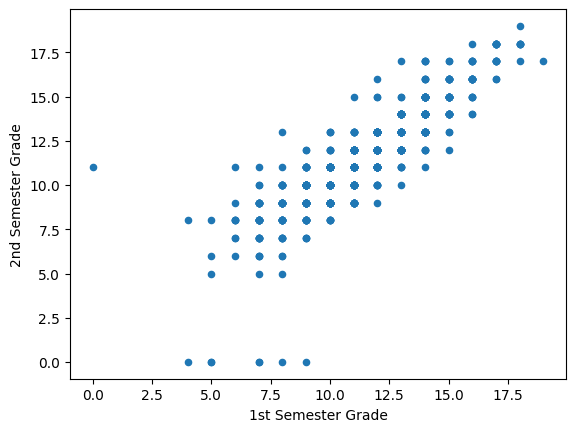

In [ ]:
# Looking for outliers where student's (most likely) inaccurately have a 0 for a semester grade
display(df.plot.scatter(x= '1st Semester Grade', y = '2nd Semester Grade'))

<Axes: xlabel='1st Semester Grade', ylabel='2nd Semester Grade'>

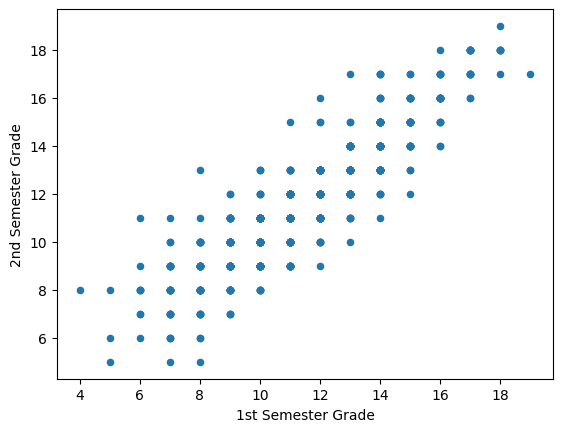

In [ ]:
# Remove students with grades of 0 in 1st
df = df.drop(df['1st Semester Grade'].nsmallest(1).index)
# Remove students with grades of 0 in 2nd semester
df = df.drop(df['2nd Semester Grade'].nsmallest(7).index)

# Check the new df
df.plot.scatter(x= '1st Semester Grade', y = '2nd Semester Grade')

In [ ]:
# Average semester grades and remove old columns
df['Grade'] = (df['1st Semester Grade'] + df['2nd Semester Grade']) / 2
df = df.drop(['1st Semester Grade', '2nd Semester Grade'], axis=1)
df.describe()

,Age,Fathers Ed.,Mothers Ed.,Study Time,Desire for Higher Ed.,Absences,Health,Weekday Alcohol Consumption,Weekend Alcohol Consumption,Grade
count,641.000000,641.000000,641.000000,641.000000,641.000000,641.000000,641.000000,641.000000,641.000000,641.000000
mean,16.730109,2.312012,2.517941,1.934477,0.102964,3.698908,3.536661,1.499220,2.277691,11.584243
std,1.214694,1.100850,1.133333,0.832211,0.304149,4.653777,1.446649,0.923859,1.282436,2.595655
min,15.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,1.000000,5.000000
25%,16.000000,1.000000,2.000000,1.000000,0.000000,0.000000,2.000000,1.000000,1.000000,9.500000
50%,17.000000,2.000000,2.000000,2.000000,0.000000,2.000000,4.000000,1.000000,2.000000,11.500000
75%,18.000000,3.000000,4.000000,2.000000,0.000000,6.000000,5.000000,2.000000,3.000000,13.500000
max,22.000000,4.000000,4.000000,4.000000,1.000000,32.000000,5.000000,5.000000,5.000000,18.500000


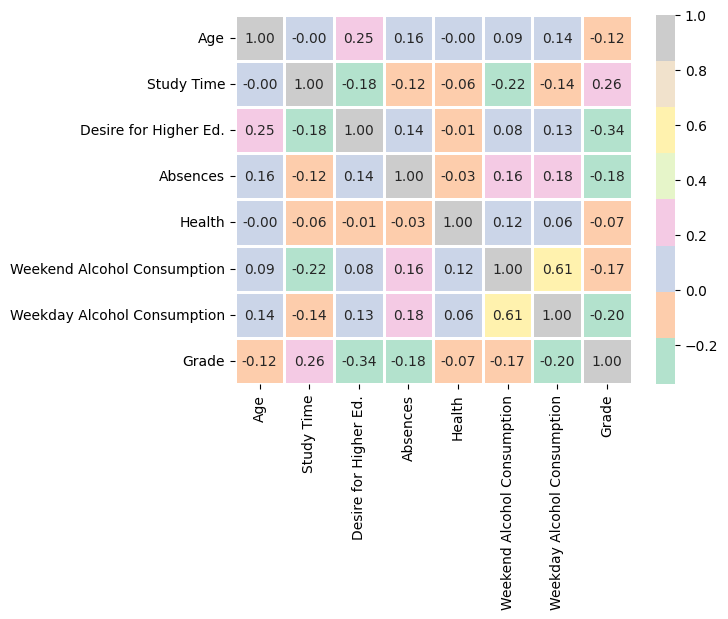

In [ ]:
# heat map of correlation between School, Sex, Age, and Grade
sns.heatmap(df[['Age',  'Study Time', 'Desire for Higher Ed.',
                'Absences', 'Health', 'Weekend Alcohol Consumption',
                'Weekday Alcohol Consumption', 'Grade']]
            .corr(), annot=True, fmt='.2f', cmap='Pastel2', linewidths=2)
plt.show()

<Axes: xlabel='Grade', ylabel='Weekend Alcohol Consumption'>

<Axes: xlabel='Grade', ylabel='Weekday Alcohol Consumption'>

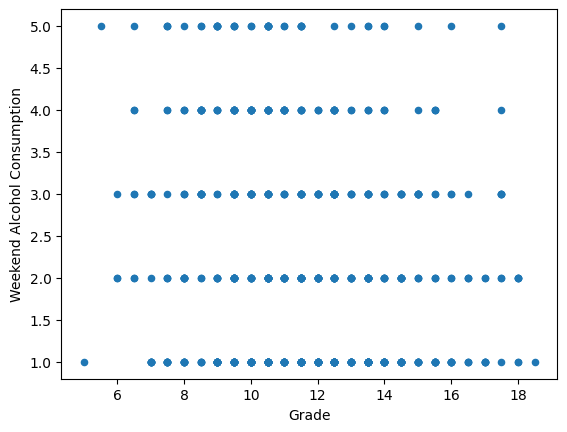

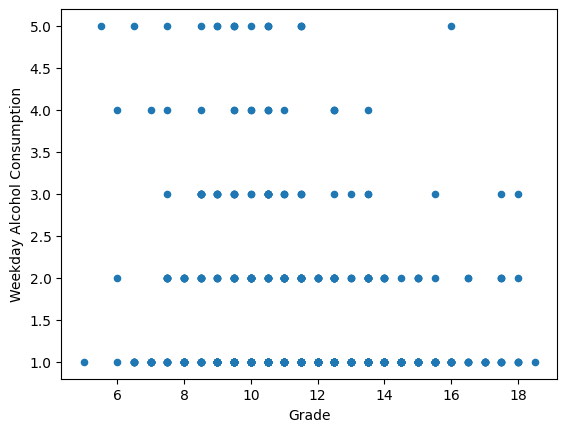

In [ ]:
# Correlation of grades and drinking habits
display(df.plot.scatter(x= 'Grade', y = 'Weekend Alcohol Consumption'))
display(df.plot.scatter(x= 'Grade', y = 'Weekday Alcohol Consumption'))

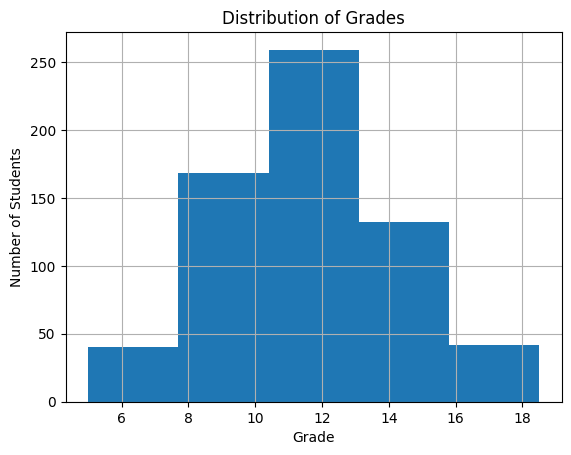

In [ ]:
# Histogram of grades and other high correlated factors
df['Grade'].hist(bins=5)
plt.title('Distribution of Grades')
plt.xlabel('Grade')
plt.ylabel('Number of Students')
plt.show()


Train data and use random forest regression

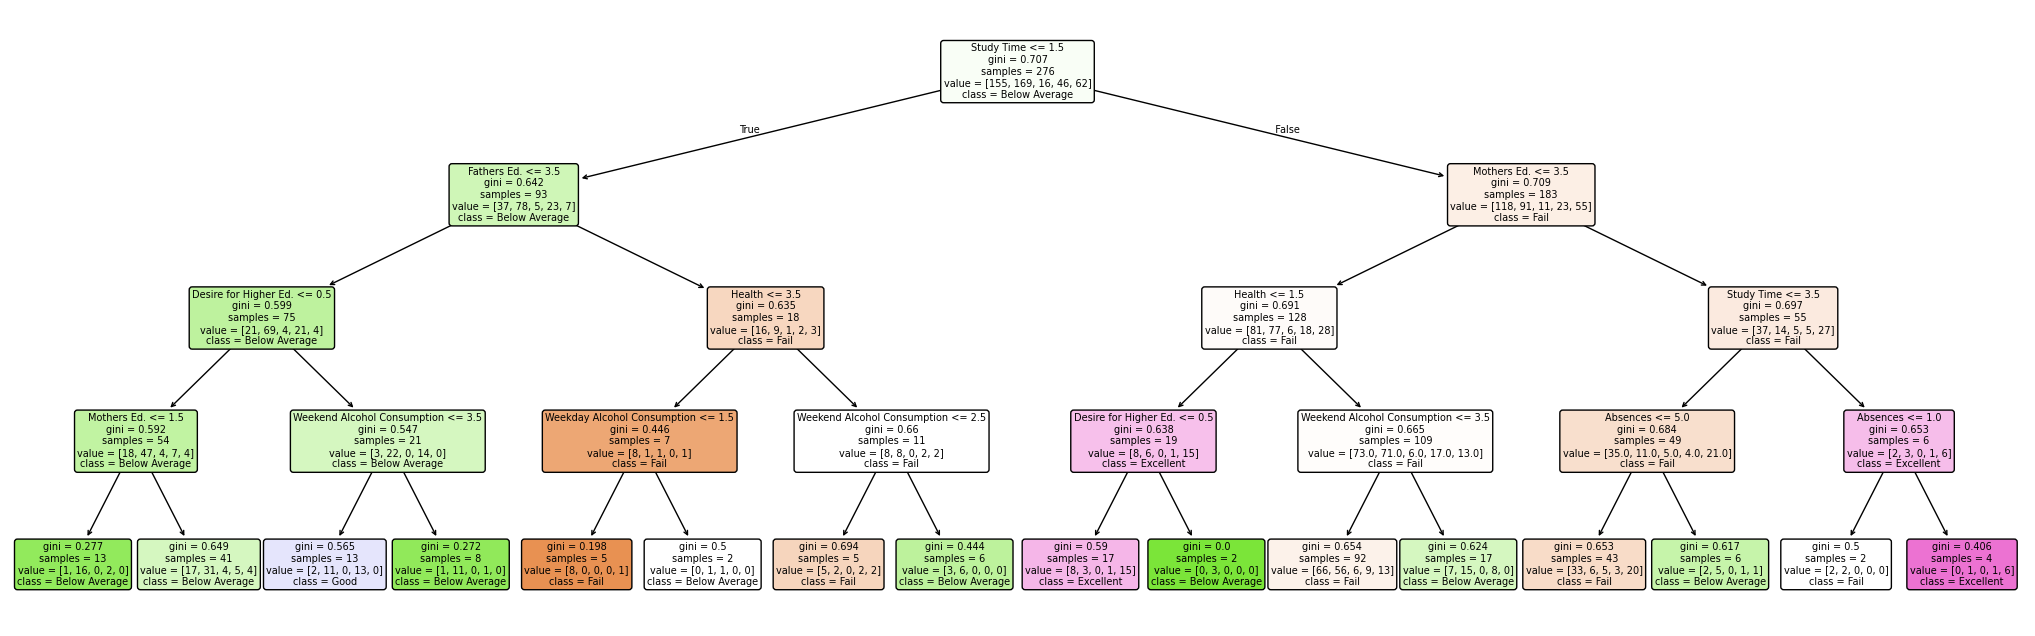

In [ ]:
# Create bins for grade
bins = [0, 8, 11, 14, 17, 20]
labels = ['Fail', 'Below Average', 'Average', 'Good', 'Excellent']
y = pd.cut(df['Grade'], bins=bins, labels=labels, include_lowest=True)

# Train and test split using stratification
x = df.drop(columns=['Grade'])
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.3, random_state=42, stratify=y
)

# Create random forest
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=4,
    random_state=42
)

# Train
rf.fit(x_train, y_train)

# Predict
y_pred = rf.predict(x_test)

# Plot one tree from the forest
plt.figure(figsize=(26,8))
plot_tree(rf.estimators_[0],
          feature_names=x.columns,
          class_names=labels,
          filled=True,
          rounded=True,
          fontsize = 7
          )
plt.show()

Ensemble of Regression Trees

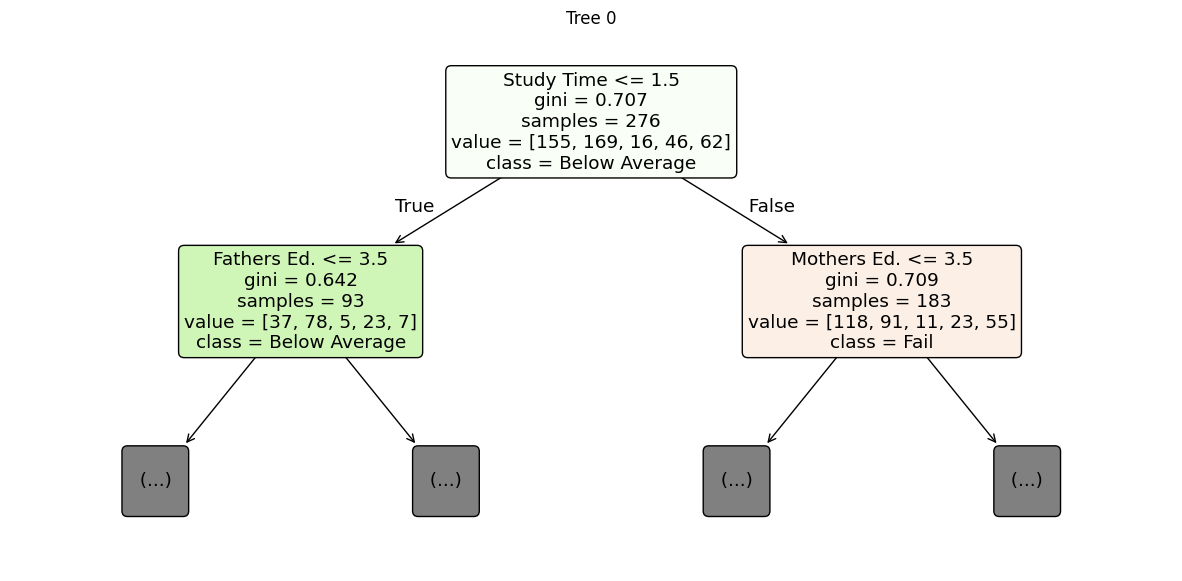

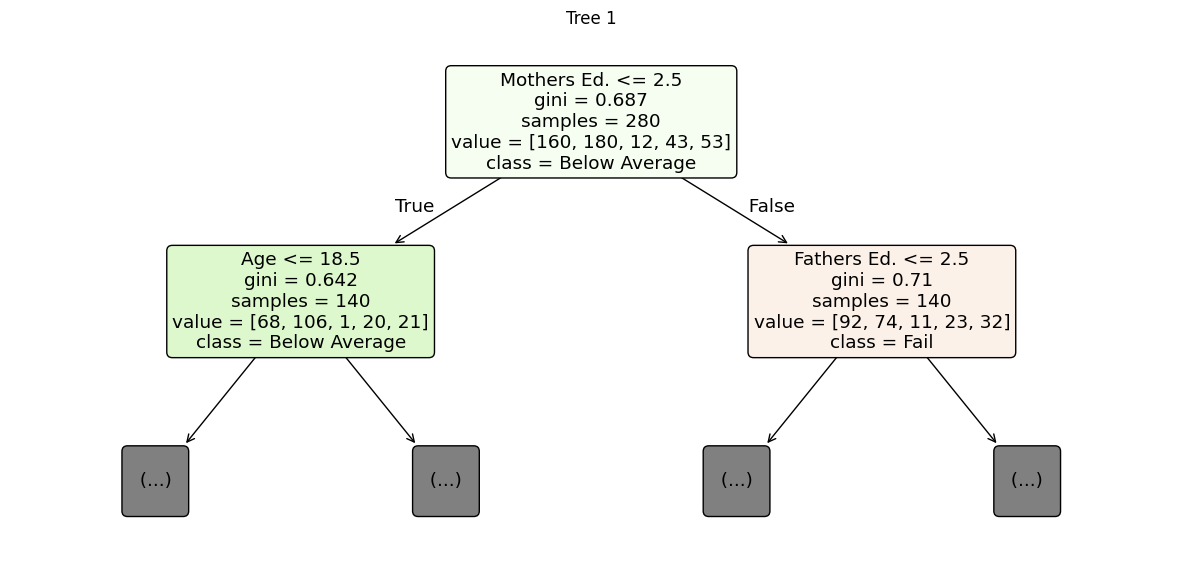

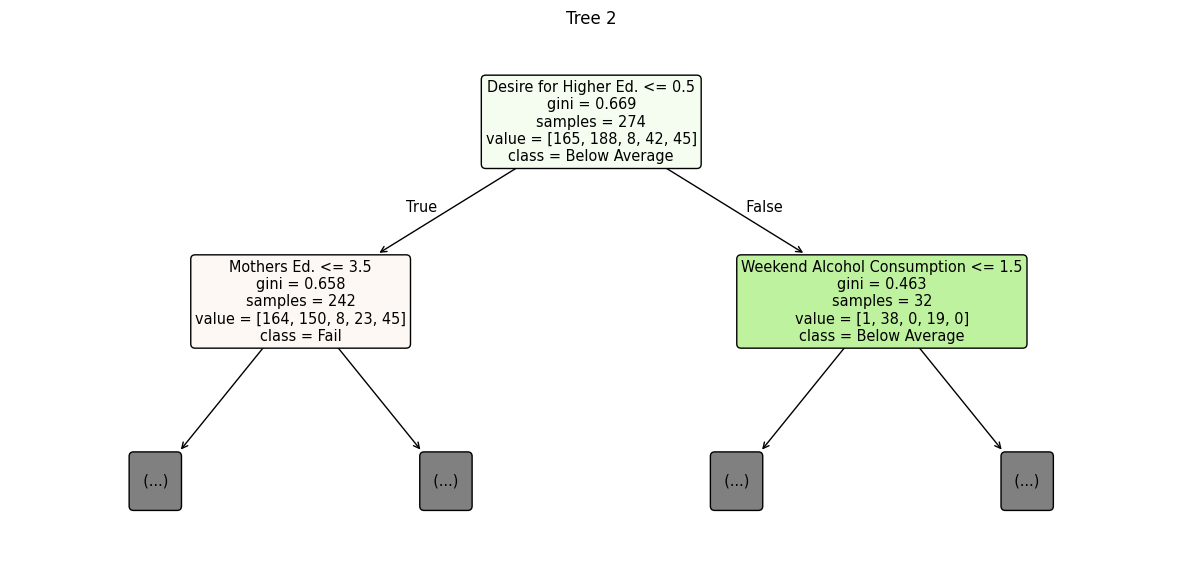

In [ ]:
# Plot the next 2 trees to compare
for i in range(0, 3):
    plt.figure(figsize=(15, 7))
    plot_tree(rf.estimators_[i],
              feature_names=x.columns,
              class_names=labels,
              filled=True,
              rounded=True,
              max_depth=1)
    plt.title(f"Tree {i}")
    plt.show()

Accuracy and check for overfitting

In [ ]:
from sklearn.metrics import classification_report

# Test set
y_test_pred = rf.predict(x_test)
print(f"Test set accuracy: {accuracy_score(y_test, y_test_pred):.4f}")
print(classification_report(y_test, y_test_pred))

# Training set
y_train_pred = rf.predict(x_train)
print(f"Training set accuracy: {accuracy_score(y_train, y_train_pred):.4f}")

Test set accuracy: 0.4819
               precision    recall  f1-score   support

      Average       0.44      0.74      0.55        70
Below Average       0.57      0.56      0.57        73
    Excellent       0.00      0.00      0.00         5
         Fail       0.00      0.00      0.00        18
         Good       0.00      0.00      0.00        27

     accuracy                           0.48       193
    macro avg       0.20      0.26      0.22       193
 weighted avg       0.37      0.48      0.41       193

Training set accuracy: 0.5603


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Plot predicted vs actual grades

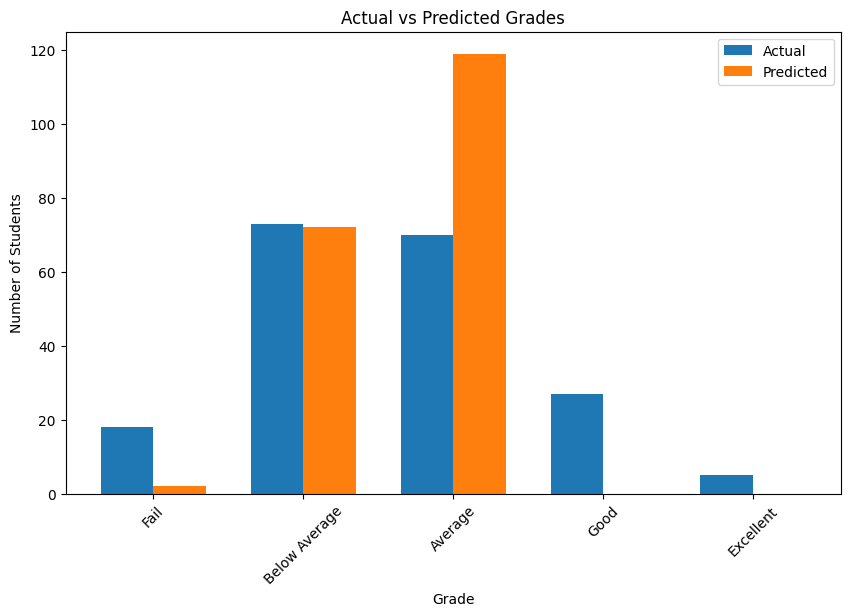

In [ ]:
# Count grades in bins
actual_counts = y_test.value_counts().reindex(labels)
pred_counts = pd.Series(y_pred).value_counts().reindex(labels, fill_value=0)

# Plot
x = np.arange(len(labels))
width = 0.35
plt.figure(figsize=(10,6))
plt.bar(x - width/2, actual_counts, width, label='Actual')
plt.bar(x + width/2, pred_counts, width, label='Predicted')
plt.xticks(x, labels, rotation=45)
plt.xlabel("Grade")
plt.ylabel("Number of Students")
plt.title("Actual vs Predicted Grades")
plt.legend()
plt.show()

In [ ]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=labels, columns=labels)
cm_df.index.name = 'Actual'
cm_df.columns.name = 'Predicted'

display(cm_df)

Predicted,Fail,Below Average,Average,Good,Excellent
Actual,,,,,
Fail,0,9,9,0,0
Below Average,2,41,30,0,0
Average,0,18,52,0,0
Good,0,4,23,0,0
Excellent,0,0,5,0,0


Feature Importance

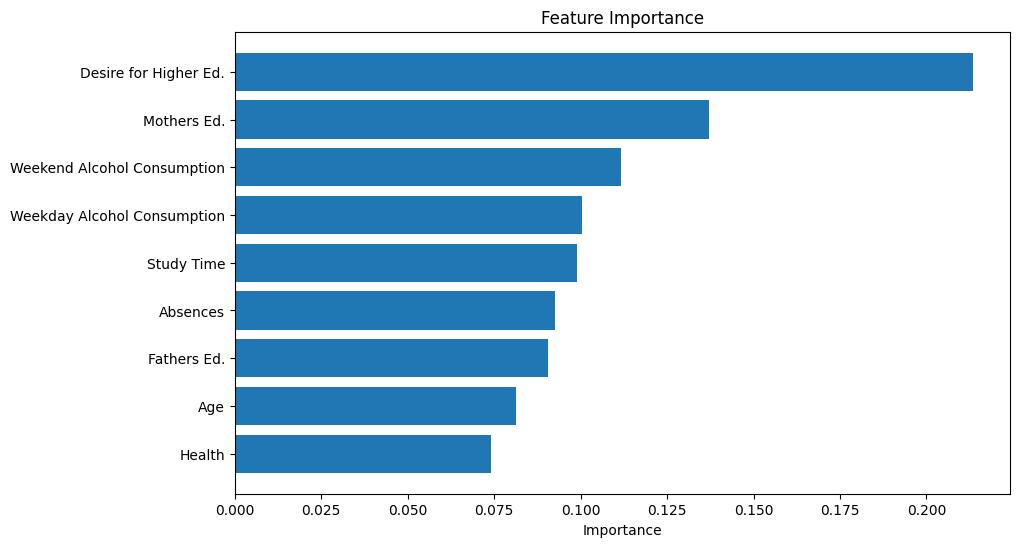

In [ ]:
# Feature importance
importances = rf.feature_importances_
features = df.drop(columns=['Grade']).columns

feat_imp = pd.DataFrame({'Feature': features, 'Importance': importances})
feat_imp = feat_imp.sort_values(by='Importance', ascending=False)
plt.figure(figsize=(10,6))
plt.barh(feat_imp['Feature'], feat_imp['Importance'])
plt.gca().invert_yaxis()  # highest importance on top
plt.xlabel('Importance')
plt.title('Feature Importance')
plt.show()